# Convolutional Autoencoder on the Emoji Dataset

## Overview

| Item | Detail |
|------|--------|
| **Architecture** | DCGAN inspired convolutional autoencoder |
| **Loss** | MSE (Mean Squared Error) + MAE (Mean Absolute Error)  |
| **Latent dim** | 128 |
| **Image resolution** | 64 × 64 × 3 |
| **Subset** | Emojis with the term 'face' in the description |
| **Splits** | 600 train / 200 val / 200 test | After augmentation

---

To achieve the highest possible reconstruction clarity, I conducted a series of systematic experiments targeting the model’s core hyperparameters and structural design. The process involved a multi-stage sweep to identify the ideal latent dimension (least loss), alongside the implementation of a MSE + L1 loss to prioritize some definition over simple pixel averaging. Furthermore, I optimized the pipeline by replacing standard bilinear interpolation (though the loss was low, the visuals were worse than nearest neighbour) with nearest-neighbor upsampling and balancing the data augmentation intensity to ensure the model learned robust aspects without sacrificing visual clarity. This iterative approach allowed for a specific configuration that minimized the blurry tendency, resulting in a latent space that is quite responsive to semantic vector arithmetic.

I read about skip connections (U-net), and on implementation, the results were amazing, but I got suspicious and upon inspection, I found that the model was hardly learning anything through latent space and was learning through the transfer of spatial features through skips. Hence, I discarded it since it was violating the spirit of latent vector arithmetic.


In [2]:
!pip install -q datasets Pillow matplotlib

In [3]:
import os
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from datasets import load_dataset


# Reproducibility

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Dataset Preparation

### Source
[valhalla/emoji-dataset](https://huggingface.co/datasets/valhalla/emoji-dataset) from HuggingFace

### Subset Selection
Filter the dataset for emojis whose text field contains "face" (case-insensitive).

### Steps
1. Loading the full dataset from HuggingFace
2. Filtering for "face" keyword in text
3. Resizing all images to 64 × 64 × 3
4. Splitting into 60% train / 20% val / 20% test
5. Applying data augmentation to expand to 600 / 200 / 200 images

In [50]:
# Load the emoji dataset from HuggingFace
dataset = load_dataset("valhalla/emoji-dataset", split="train")
print(f"Total emojis in dataset: {len(dataset)}")

# Filter for "face" emojis
FILTER_KEYWORD = "face"
face_indices = [
    i for i, text in enumerate(dataset['text'])
    if FILTER_KEYWORD.lower() in text.lower()
]
face_dataset = dataset.select(face_indices)
print(f'Emojis containing "{FILTER_KEYWORD}": {len(face_dataset)}')

# Print some example text labels
print("\nSample labels:")
for i in range(10):
    print(f"  {i+1}. {face_dataset[i]['text']}")

Total emojis in dataset: 2749
Emojis containing "face": 204

Sample labels:
  1. grinning face
  2. smiling face with open mouth
  3. winking face
  4. robot face
  5. smiling cat face with open mouth
  6. grinning cat face with smiling eyes
  7. cat face with tears of joy
  8. smiling cat face with heart shaped eyes
  9. cat face with wry smile
  10. kissing cat face with closed eyes


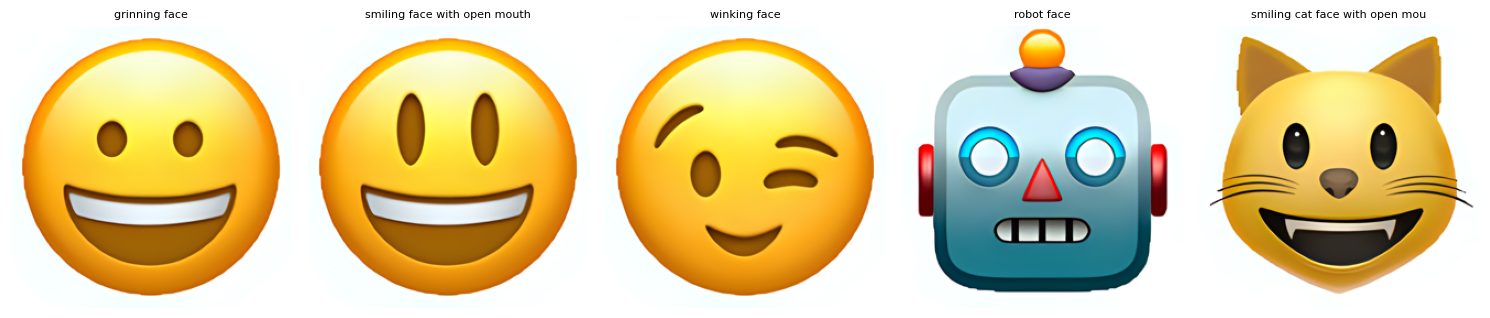

In [5]:
# Display sample emojis from the filtered subset
fig, axes = plt.subplots(1, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i < len(face_dataset):
        img = face_dataset[i]['image']
        ax.imshow(img)
        ax.set_title(face_dataset[i]['text'][:30], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
IMG_SIZE = 64

# Standardze to RGB format and resize
def resize_image(img, size=IMG_SIZE):
    return img.convert('RGB').resize((size, size), Image.BILINEAR)

# Collect and resize all filtered images
all_images = [resize_image(face_dataset[i]['image']) for i in range(len(face_dataset))]
all_labels = [face_dataset[i]['text'] for i in range(len(face_dataset))]
print(f"Resized {len(all_images)} images to {IMG_SIZE}x{IMG_SIZE}")

# Shuffle and split 60/20/20
indices = list(range(len(all_images)))
random.shuffle(indices)

n_total = len(indices)
n_train = int(0.6 * n_total)
n_val = int(0.2 * n_total)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

train_images = [all_images[i] for i in train_indices]
val_images   = [all_images[i] for i in val_indices]
test_images  = [all_images[i] for i in test_indices]

print(f"Base splits -> Train: {len(train_images)}, Val: {len(val_images)}, Test: {len(test_images)}")

Resized 204 images to 64x64
Base splits -> Train: 122, Val: 40, Test: 42


### Data Augmentation


| Transform | Parameters |
|-----------|-----------|
| Random horizontal flip | p=0.5 |
| Random rotation | ±10° |
| Color jitter | brightness=0.2, contrast=0.2, saturation=0.2 |
| Random affine | translate=5%, scale=0.9–1.1 |


In [115]:
# Data augmentation transforms
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

to_tensor = transforms.ToTensor()  # Converts PIL [0,255] → Tensor [0,1]

def augment_split(images, target_count):
    """Augment a list of PIL images to reach target_count total images."""
    augmented = []
    # Include all originals first
    for img in images:
        augmented.append(to_tensor(img))
    # Generate augmented copies until we reach the target
    while len(augmented) < target_count:
        img = random.choice(images)
        aug_img = augmentation_transforms(img)
        augmented.append(to_tensor(aug_img))
    return augmented[:target_count]

# Target sizes
TARGET_TRAIN = 600
TARGET_VAL   = 200
TARGET_TEST  = 200

train_tensors = augment_split(train_images, TARGET_TRAIN)
val_tensors   = augment_split(val_images, TARGET_VAL)
test_tensors  = augment_split(test_images, TARGET_TEST)

print(f"Augmented splits — Train: {len(train_tensors)}, Val: {len(val_tensors)}, Test: {len(test_tensors)}")
print(f"Tensor shape: {train_tensors[0].shape}")  # [3, 64, 64]
print(f"Value range: [{train_tensors[0].min():.3f}, {train_tensors[0].max():.3f}]")

Augmented splits — Train: 600, Val: 200, Test: 200
Tensor shape: torch.Size([3, 64, 64])
Value range: [0.035, 1.000]


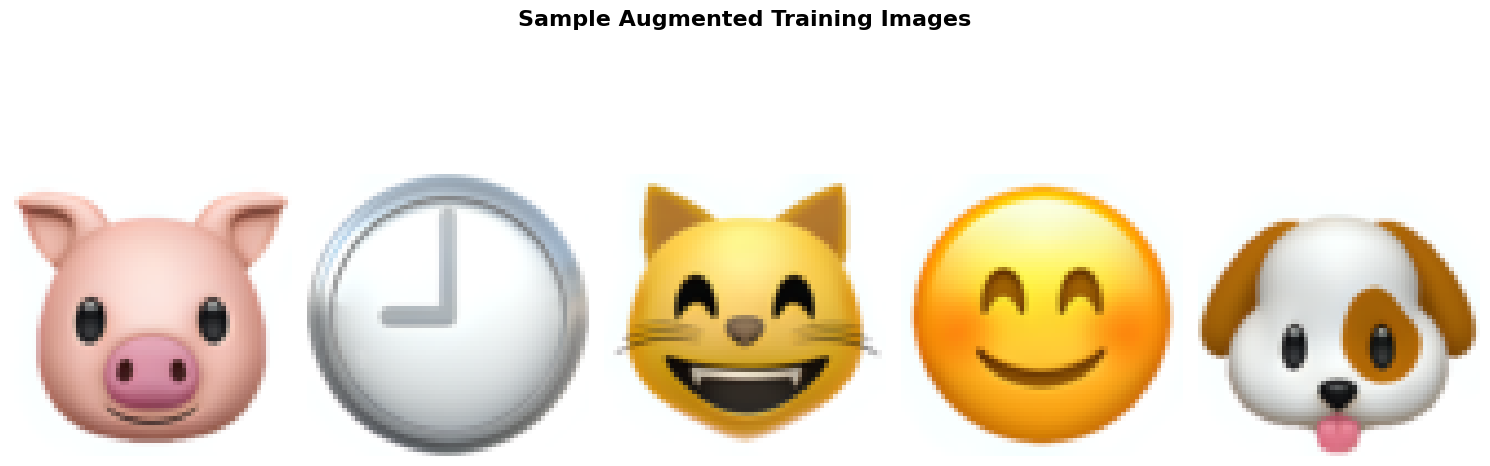

In [106]:
# Print some augmented training images
fig, axes = plt.subplots(1, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = train_tensors[i].permute(1, 2, 0).numpy()
    ax.imshow(np.clip(img, 0, 1))
    ax.axis('off')

plt.tight_layout()
plt.show()

In [116]:
class EmojiDataset(Dataset):

    def __init__(self, tensor_list):
        self.data = torch.stack(tensor_list)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        return x, x

BATCH_SIZE = 32

train_dataset = EmojiDataset(train_tensors)
val_dataset   = EmojiDataset(val_tensors)
test_dataset  = EmojiDataset(test_tensors)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")
print(f"Total — Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train batches: 19, Val batches: 7, Test batches: 7
Total — Train: 600, Val: 200, Test: 200


## 2. Autoencoder

In [117]:
import torch
import torch.nn as nn

class ConvAutoencoder(nn.Module):
    """
    Encoder: 4 strided conv layers → flatten → FC to latent space
    Decoder: FC → reshape → 4 upsample + conv layers → output
    """
    def __init__(self, latent_dim=128):
        super(ConvAutoencoder, self).__init__()
        self.latent_dim = latent_dim

        # ========================
        # Encoder
        # ========================
        # 3 x 64 x 64 → 32 x 32 x 32
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # 32 x 32 x 32 → 64 x 16 x 16
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # 64 x 16 x 16 → 128 x 8 x 8
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # 128 x 8 x 8 → 256 x 4 x 4
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.encoder_fc = nn.Linear(256 * 4 * 4, latent_dim)

        # ========================
        # Decoder
        # ========================
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)

        # 256x4x4 → upsample → 8x8, conv → 128x8x8
        self.dec1 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

        self.dec2 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        self.dec3 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        self.dec4 = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid(),
        )

        # Initialize weights
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def encode(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)
        x = self.enc4(x)
        flat = x.view(x.size(0), -1)
        z = self.encoder_fc(flat)
        return z

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 256, 4, 4)

        x = self.dec1(x)                         # 128 x 8 x 8
        x = self.dec2(x)                         # 64 x 16 x 16
        x = self.dec3(x)                         # 32 x 32 x 32
        x = self.dec4(x)                         # 3 x 64 x 64
        return x

    def forward(self, x):
        z = self.encode(x)
        x_recon = self.decode(z)
        return x_recon, z

In [118]:
# Instantiate model
LATENT_DIM = 128
model = ConvAutoencoder(latent_dim=LATENT_DIM).to(device)

## 3. Training

### Hyperparameters

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Loss function | MSE + L1 (λ=0.1) | MSE is primary, L1 to preserve sharpness and edges |
| Optimizer | Adam | Adaptive learning rates usually work well for conv nets |
| Learning rate | 1e-3 | Standard starting point for Adam |
| Weight decay | 1e-5 | L2 regularization to prevent overfitting on small dataset |
| Batch size | 32 | Seems reasonable |
| Max epochs | 200 | Sufficient for convergence with early stopping |
| Early stopping | patience=25 | Stops training when no improvement for 25 epochs |
| Seed | 42 | For reproducibility |

In [119]:
# =========================
# Hyperparameters
# =========================

LEARNING_RATE = 0.001
WEIGHT_DECAY  = 0.00001
EPOCHS        = 200
PATIENCE      = 25
L1_LAMBDA     = 0.05   # Weight for L1 loss component (sharpness)

# Loss, Optimizer, Scheduler

mse_criterion = nn.MSELoss()
l1_criterion  = nn.L1Loss()


def combined_loss(output, target):
    mse = mse_criterion(output, target)
    l1 = l1_criterion(output, target)
    return mse + (L1_LAMBDA * l1)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

# =========================
# Training loop
# =========================

train_losses = []
val_losses   = []

best_val_loss    = float('inf')
patience_counter = 0
best_model_state = None

print("Starting training...")
print(f"Loss = MSE + {L1_LAMBDA} * L1")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    # --- Training phase ---
    model.train()
    running_train_loss = 0.0
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        output, latent = model(batch_x)
        loss = combined_loss(output, batch_y)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * batch_x.size(0)

    avg_train_loss = running_train_loss / len(train_dataset)

    # --- Validation phase ---
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            output, latent = model(batch_x)
            loss = combined_loss(output, batch_y)
            running_val_loss += loss.item() * batch_x.size(0)

    avg_val_loss = running_val_loss / len(val_dataset)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Adjust learning rate
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Print every 10 epochs (or first epoch)
    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:6d} | {avg_train_loss:12.6f} | {avg_val_loss:12.6f} | {current_lr:10.2e}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}. Best val loss: {best_val_loss:.6f}")
            break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"\n{'=' * 50}")
print(f"Training complete after {len(train_losses)} epochs.")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"{'=' * 50}")

Starting training...
Loss = MSE + 0.05 * L1
 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
     1 |     0.106791 |     0.088965 |   1.00e-03
    10 |     0.029631 |     0.034556 |   1.00e-03
    20 |     0.022486 |     0.028989 |   1.00e-03
    30 |     0.018834 |     0.026817 |   1.00e-03
    40 |     0.016534 |     0.027196 |   1.00e-03
    50 |     0.015457 |     0.024783 |   1.00e-03
    60 |     0.014380 |     0.025225 |   1.00e-03
    70 |     0.010497 |     0.022950 |   5.00e-04
    80 |     0.009681 |     0.022594 |   2.50e-04
    90 |     0.008933 |     0.022664 |   1.25e-04

Early stopping at epoch 91. Best val loss: 0.022369

Training complete after 91 epochs.
Best validation loss: 0.022369


## 4. Results

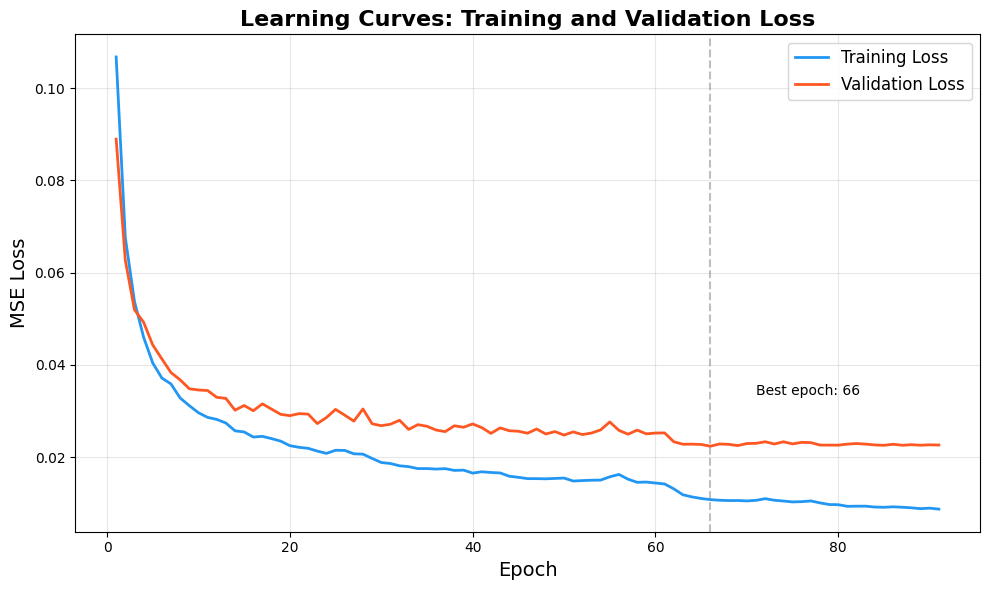

In [124]:
# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(1, len(train_losses) + 1), train_losses,
        label='Training Loss', linewidth=2, color='#2196F3')
ax.plot(range(1, len(val_losses) + 1), val_losses,
        label='Validation Loss', linewidth=2, color='#FF5722')

ax.set_xlabel('Epoch', fontsize=14)
ax.set_ylabel('MSE Loss', fontsize=14)
ax.set_title('Learning Curves: Training and Validation Loss', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Add annotation
best_epoch = np.argmin(val_losses) + 1
ax.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.5)
ax.annotate(f'Best epoch: {best_epoch}',
            xy=(best_epoch, val_losses[best_epoch-1]),
            xytext=(best_epoch + 5, val_losses[best_epoch-1] * 1.5))

plt.tight_layout()
plt.show()

In [121]:
# Evaluate on test set
model.eval()
test_loss   = 0.0
all_latents = []
all_inputs  = []
all_outputs = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        output, latent = model(batch_x)
        loss = combined_loss(output, batch_y)
        test_loss += loss.item() * batch_x.size(0)

        all_latents.append(latent.cpu())
        all_inputs.append(batch_x.cpu())
        all_outputs.append(output.cpu())

avg_test_loss = test_loss / len(test_dataset)

print("=" * 50)
print(f"  FINAL TEST SET MSE: {avg_test_loss:.6f}")
print("=" * 50)

# Concatenate all results
all_latents = torch.cat(all_latents, dim=0).numpy()
all_inputs  = torch.cat(all_inputs, dim=0)
all_outputs = torch.cat(all_outputs, dim=0)

print(f"\nTest images:  {all_inputs.shape}")
print(f"Latent codes: {all_latents.shape}")

  FINAL TEST SET MSE: 0.024514

Test images:  torch.Size([200, 3, 64, 64])
Latent codes: (200, 128)


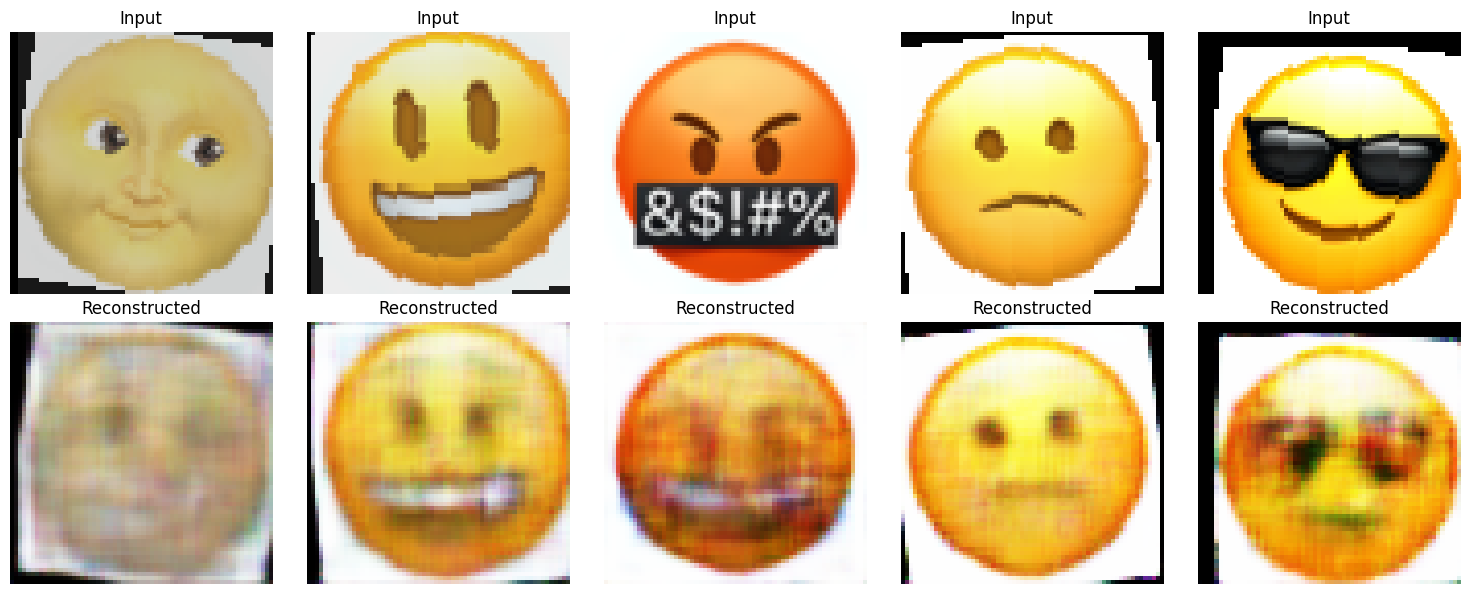

In [128]:
# Comparison of 5 input/output pairs
n_display = 5
display_indices = random.sample(range(len(all_inputs)), n_display)

fig, axes = plt.subplots(2, n_display, figsize=(3 * n_display, 6))

for i, idx in enumerate(display_indices):
    # Input image
    inp = all_inputs[idx].permute(1, 2, 0).numpy()
    axes[0, i].imshow(np.clip(inp, 0, 1))
    axes[0, i].set_title('Input', fontsize=12)
    axes[0, i].axis('off')

    # Reconstructed image
    out = all_outputs[idx].permute(1, 2, 0).numpy()
    axes[1, i].imshow(np.clip(out, 0, 1))
    axes[1, i].set_title('Reconstructed', fontsize=12)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [134]:
"""Saving the model wieghts and latent representation
I will attach them in the Canvassubmission
This cell can be skipped"""

import os
import torch
import numpy as np

os.makedirs('results', exist_ok=True)

checkpoint = {
    'model_state_dict': model.state_dict(),
    'latent_dim': 128,
    'img_size': 64,
    'best_val_loss': best_val_loss,
    'hyperparameters': {
        'learning_rate': 0.001,
        'weight_decay': 1e-5,
    }
}

torch.save(checkpoint, 'results/autoencoder_checkpoint.pth')
print(f"✅ Model weights and metadata saved to results/autoencoder_checkpoint.pth")



def save_latent_representations(model, dataloader, filename):
    model.eval()
    all_latents = []

    with torch.no_grad():
        for x, _ in dataloader:
            x = x.to(device)
            z = model.encode(x)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)

    np.save(filename, all_latents)
    print(f"✅ Saved {all_latents.shape[0]} latent vectors to {filename}")
    return all_latents

test_latents = save_latent_representations(model, test_loader, 'results/test_latents.npy')

✅ Model weights and metadata saved to results/autoencoder_checkpoint.pth
✅ Saved 200 latent vectors to results/test_latents.npy


## 5. Discussion and Observations

### Dataset
- I selected **"face"** emojis, yielding a subset of structurally similar images that share common features (eyes, mouth, overall round shape).
- After filtering and resizing to 64×64, the original subset was split 60/20/20 and augmented using random flips, rotations, color jitter, and affine transforms to reach **600 / 200 / 200** images.

### Architecture Choices
- CGAN-Inspired Core: The encoder uses four strided convolutional layers to progressively downsample the $64 \times 64$ input into a $4 \times 4$ feature map. Each layer utilizes BatchNorm and LeakyReLU to maintain stable gradient flow and prevent dead neurons.

- Sharp Decoder Upsampling: To increase resolution, the decoder uses Nearest-Neighbor Upsampling followed by $3 \times 3$ convolutions. This specific choice was made to prioritize sharpness; nearest-neighbor avoids the blurry averaging effect of bilinear interpolation (which I tried earlier and it was producing more smudgy emojis even though the loss was low), preserving the distinct edges of the emoji icons.

- By using Upsample + Conv2d instead of ConvTranspose2d, the architecture inherently avoids checkerboard artifacts. This leads to cleaner, more uniform color surfaces in the final reconstructed faces.

- Layer-Specific Initialization: The weights were initialized using Kaiming (He) Normal for the convolutional layers (optimized for ReLU/LeakyReLU) and Xavier Normal for the Linear bottleneck layers. This ensures the model starts with a balanced signal variance, allowing for faster convergence on the small 600-image training set.

### Loss Function
- While MSE is the primary loss, I incorporated L1 loss ($\lambda=0.05$). MSE was producing highly blurry results by penalizing large outliers heavily. Adding L1 probably encouraged the model to be more precise with individual pixel values.

### Training Observations
- The combined loss decreases steadily during training for both train and validation sets.
- **ReduceLROnPlateau** scheduler kicks in when the validation loss plateaus, allowing the model to fine-tune at lower learning rates.
- **Early stopping** prevents overfitting, especially given the relatively small dataset.
- **Weight decay (L2 regularization)** helps prevent overfitting on the augmented dataset.

### Reconstruction Quality
- The model produces decent reconstruction quality in which the broad shape and colour features are preserved, whereas finer details or parts of the face are somewhat blurry.
- The combined MSE+L1 loss produces noticeably crisper edges compared to MSE alone.



In [133]:
# Final summary
print("=" * 60)
print("  EXPERIMENT SUMMARY")
print("=" * 60)
print(f"  Dataset:            valhalla/emoji-dataset ('{FILTER_KEYWORD}' subset)")
print(f"  Image size:         {IMG_SIZE} x {IMG_SIZE} x 3")
print(f"  Train / Val / Test: {len(train_dataset)} / {len(val_dataset)} / {len(test_dataset)}")
print(f"  Latent dimension:   {LATENT_DIM}")
print(f"  Total parameters:   {total_params:,}")
print(f"  Loss function:      MSE + 0.05*L1")
print(f"  Optimizer:          Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Epochs trained:     {len(train_losses)}")
print(f"  Best val MSE:       {best_val_loss:.6f}")
print(f"  Final test MSE:     {avg_test_loss:.6f}")
print("=" * 60)

  EXPERIMENT SUMMARY
  Dataset:            valhalla/emoji-dataset ('face' subset)
  Image size:         64 x 64 x 3
  Train / Val / Test: 600 / 200 / 200
  Latent dimension:   128
  Total parameters:   2,132,515
  Loss function:      MSE + 0.05*L1
  Optimizer:          Adam (lr=0.001, wd=1e-05)
  Epochs trained:     91
  Best val MSE:       0.022369
  Final test MSE:     0.024514


---

# Part 2: Latent Vector Arithmetic

## Approach

We use **vector arithmetic** on the learned latent representations to transfer visual attributes between emojis. The core idea:

```
attribute_vector = encode(attribute_emoji) − encode(base_emoji)
composite_latent = encode(target_emoji) + attribute_vector
composite_image  = decode(composite_latent)
```

For example, to add **glasses** to a face:
- `glasses_vector = encode("nerd face") − encode("smiling face")`
- `composite = encode("face with tongue") + glasses_vector`



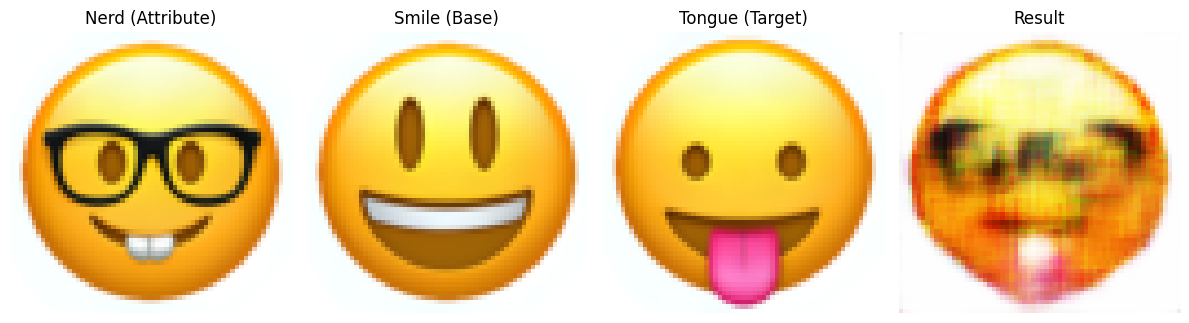

In [123]:
# --- Helper Function ---
def get_emoji_by_idx(idx):
    raw_img = dataset[idx]['image']
    img = raw_img.convert('RGB').resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return to_tensor(img).to(device)

# --- Latent Arithmetic Execution ---
ID_NERD    = 2306
ID_SMILE   = 1
ID_TONGUE  = 1335

model.eval()
with torch.no_grad():
    # 1. Extract Latents
    z_nerd  = model.encode(get_emoji_by_idx(ID_NERD).unsqueeze(0))
    z_smile = model.encode(get_emoji_by_idx(ID_SMILE).unsqueeze(0))
    z_target = model.encode(get_emoji_by_idx(ID_TONGUE).unsqueeze(0))

    # 2. Perform Math: Target + (Nerd - Smile)
    z_composite = z_target + (z_nerd - z_smile)

    # 3. Decode the result
    composite_img = model.decode(z_composite).cpu().squeeze(0)

# --- 4. Display Results ---

plt.figure(figsize=(12, 4))
titles = ['Nerd (Attribute)', 'Smile (Base)', 'Tongue (Target)', 'Result']
images = [get_emoji_by_idx(ID_NERD).cpu(), get_emoji_by_idx(ID_SMILE).cpu(),
          get_emoji_by_idx(ID_TONGUE).cpu(), composite_img]

for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

## Part 2: Discussion


### Qualitative Evaluation
- **Shape transfer**: The composite image shows the target face (tongue) with modifications in the eye/upper-face region corresponding to the glasses attribute.
- **Color preservation**: The overall color palette of the target is mostly preserved.
- **Attribute blending**: The glasses attribute is partially visible in the composite


### Ways to Improve Quality
1. **Higher resolution** (128×128 or 256×256) would allow finer attribute details to be preserved.
2. **Variational autoencoder (VAE)**: imposing a structured prior (Gaussian) on the latent space might make vector arithmetic more reliable, since the latent space would be smoother and more regular.
3. **Adversarial training (GAN)** might encourage the decoder to produce sharper, more realistic outputs.
4. **Larger training set**: training on more emojis would help the model generalize attribute concepts beyond the training distribution.
5. **Weighted arithmetic**: tuning the coefficient on the attribute vector (e.g., target + λ * attribute_vector) might control the strength of the transferred attribute.